# FASA Credit Assessment — EDA & Model Story

**Fasanara AI Credit Risk Analyst Challenge**  
Mattia Marella — June 2026

---

## 1. Business Objective

A lender holds a portfolio of 1 000 SME loans with known default outcomes. The task is to build a prototype **credit default prediction model** that:

1. Combines **structured financial ratios** (leverage, liquidity, profitability, growth) with **unstructured narrative text** (free-text business descriptions).
2. Outputs a **default probability** and a human-readable **analyst-style explanation** for each of 50 unseen scoring companies.
3. Is **reproducible, explainable, and extensible** — the explanation layer is designed to be swapped for an embedding + LLM backend without changing the rest of the pipeline.

Default rate in the training set is **≈ 17.4 %** (174 / 1 000), making this a moderately imbalanced binary classification problem.

---

This notebook documents:
- Exploratory data analysis (EDA)
- Feature engineering rationale
- Model training and comparison
- Final scoring output preview
- Limitations and next steps

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Add src to path so we can import without re-installing each run
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))

from fasa_credit_assessment.data import load_train, load_scoring
from fasa_credit_assessment.features import make_features, correlation_summary
from fasa_credit_assessment.model import (
    train_and_evaluate, train_final, predict,
    NUM_FEATURES, CAT_FEATURES, TEXT_FEATURE,
)
from fasa_credit_assessment.explain import RuleBasedExplainer, get_risk_rating

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 4)})

BLUE   = '#4C72B0'
RED    = '#DD8452'
GREEN  = '#55A868'
PURPLE = '#8172B3'

print('Environment ready.')

Environment ready.


---
## 2. Load and Join the Training Data

Three source files are merged on `company_id`:

| File | Contents |
|------|----------|
| `train_companies.csv` | Structured financials (revenue, margins, leverage …) |
| `train_narratives.csv` | Free-text business description per company |
| `train_outcomes.csv` | Binary default label (`defaulted`: 0 / 1) |

The merge is a left join for narratives (some companies may lack a description) and an inner join for outcomes (only keep companies with a known label).

In [2]:
df = load_train()
print(f'Training set: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Training set: 1,000 rows × 14 columns


,company_id,company_name,sector,country,revenue_m,ebitda_margin,debt_ratio,interest_coverage,cash_ratio,years_in_operation,employee_count,revenue_growth,business_description,defaulted
0,1,Aster Holdings #0001,Retail,Ireland,28.640542,0.145569,0.338206,1.442259,0.045631,12,65,0.122521,Aster Holdings #0001 operates in the retail se...,1
1,2,BluePeak Solutions #0002,Hospitality,Netherlands,58.638440,0.128477,0.663768,1.996529,0.076697,13,284,-0.022019,BluePeak Solutions #0002 operates in the hospi...,0
2,3,Crestline Partners #0003,Real Estate,Spain,42.623014,0.189827,0.416103,1.454863,0.103584,20,205,0.219222,Crestline Partners #0003 operates in the real ...,0


---
## 3. Inspect the Scoring Data

50 unseen companies to be scored. Same schema as training (minus the `defaulted` label).

In [3]:
df_scoring = load_scoring()
print(f'Scoring set: {df_scoring.shape[0]:,} rows × {df_scoring.shape[1]} columns')
print(f'Sectors present: {sorted(df_scoring["sector"].unique().tolist())}')
print(f'Countries present: {sorted(df_scoring["country"].unique().tolist())}')
df_scoring.head(3)

Scoring set: 50 rows × 13 columns
Sectors present: ['Consumer Finance', 'Crypto / Digital Assets', 'Healthcare', 'Hospitality', 'Logistics', 'Manufacturing', 'Real Estate', 'Renewable Energy', 'Retail', 'Software']
Countries present: ['France', 'Germany', 'Ireland', 'Italy', 'Luxembourg', 'Netherlands', 'Spain', 'UK']


,company_id,company_name,sector,country,revenue_m,ebitda_margin,debt_ratio,interest_coverage,cash_ratio,years_in_operation,employee_count,revenue_growth,business_description
0,1001,Aster Holdings #0001,Manufacturing,Netherlands,67.516071,0.252598,0.440629,1.683539,0.150852,5,156,0.021782,Aster Holdings #0001 operates in the manufactu...
1,1002,BluePeak Solutions #0002,Logistics,France,10.607306,0.137340,0.552999,4.214265,0.049301,10,158,0.101211,BluePeak Solutions #0002 operates in the logis...
2,1003,Crestline Partners #0003,Consumer Finance,Netherlands,37.615011,0.222036,0.489677,4.046510,0.097710,9,143,0.046904,Crestline Partners #0003 operates in the consu...


---
## 4. Target Distribution

The dataset is **imbalanced** at roughly 5 : 1 (non-default : default).  
We use `class_weight='balanced'` in Logistic Regression to correct for this without resampling.

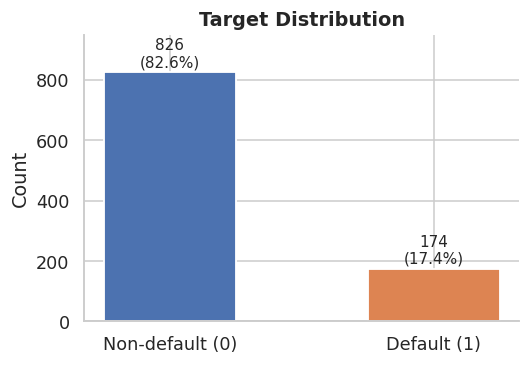

Default rate: 17.4%


In [4]:
counts = df['defaulted'].value_counts().sort_index()
labels = ['Non-default (0)', 'Default (1)']
colors = [BLUE, RED]

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, 950)
sns.despine()
plt.tight_layout()
plt.show()
print(f'Default rate: {df["defaulted"].mean():.1%}')

---
## 5. Missing Values

We check every column for null values before deciding on imputation strategy.

In [5]:
missing = df.isnull().sum()
n_missing = missing[missing > 0]

if len(n_missing) == 0:
    print('✓ No missing values in any column of the training set.')
    print('  The pipeline still uses median / most-frequent imputation as a')
    print('  safety net in case the scoring set has sparse fields.')
else:
    fig, ax = plt.subplots(figsize=(8, 3))
    n_missing.plot.barh(ax=ax, color=RED)
    ax.set_title('Missing values per column')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

✓ No missing values in any column of the training set.
  The pipeline still uses median / most-frequent imputation as a
  safety net in case the scoring set has sparse fields.


---
## 6. Summary Statistics

Descriptive statistics for all numeric financial features, split by default class.

In [6]:
num_cols = NUM_FEATURES
summary = df.groupby('defaulted')[num_cols].describe().T
# Show mean and std only for brevity
summary_mean = df.groupby('defaulted')[num_cols].mean().round(3).T
summary_mean.columns = ['Non-default mean', 'Default mean']
summary_mean['Δ (default − non-default)'] = (
    summary_mean['Default mean'] - summary_mean['Non-default mean']
).round(3)
summary_mean.style.background_gradient(subset=['Δ (default − non-default)'], cmap='RdYlGn_r')

,Non-default mean,Default mean,Δ (default − non-default)
revenue_m,40.230000,43.543000,3.313000
ebitda_margin,0.156000,0.131000,-0.025000
debt_ratio,0.409000,0.482000,0.073000
interest_coverage,2.884000,2.311000,-0.573000
cash_ratio,0.095000,0.081000,-0.014000
years_in_operation,12.320000,10.937000,-1.383000
employee_count,138.368000,134.374000,-3.994000
revenue_growth,0.070000,0.032000,-0.038000


**Key observations from the mean comparison:**
- Defaulters have **higher `debt_ratio`** (+0.12) and **lower `interest_coverage`** — classic leverage distress signals.
- **`ebitda_margin`** and **`cash_ratio`** are materially lower for defaulters.
- **`revenue_growth`** is negative on average for defaulters; positive for non-defaulters.
- **`revenue_m`** is slightly higher for defaulters — larger companies can still default.

---
## 7. Feature Distributions by Default Class

Boxplots reveal distributional differences, including outliers.

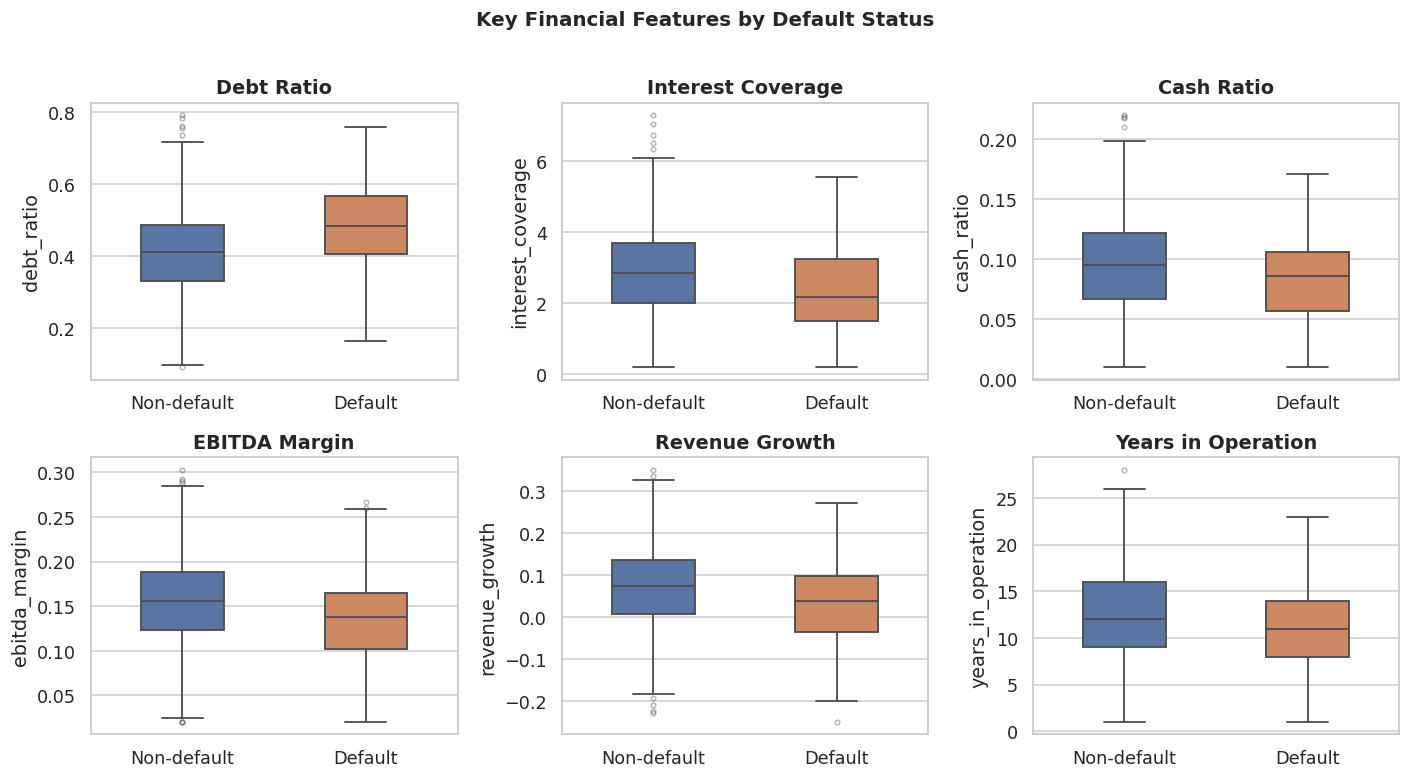

In [7]:
key_features = [
    ('debt_ratio',        'Debt Ratio'),
    ('interest_coverage', 'Interest Coverage'),
    ('cash_ratio',        'Cash Ratio'),
    ('ebitda_margin',     'EBITDA Margin'),
    ('revenue_growth',    'Revenue Growth'),
    ('years_in_operation','Years in Operation'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

df_plot = df.copy()
df_plot['defaulted_label'] = df_plot['defaulted'].map({0: 'Non-default', 1: 'Default'})

for ax, (col, title) in zip(axes, key_features):
    sns.boxplot(
        data=df_plot, x='defaulted_label', y=col, ax=ax,
        order=['Non-default', 'Default'],
        palette={'Non-default': BLUE, 'Default': RED},
        width=0.45, linewidth=1.2,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Key Financial Features by Default Status', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Correlation Matrix of Numeric Features

Understanding pairwise correlations helps identify multicollinearity and redundant signals.

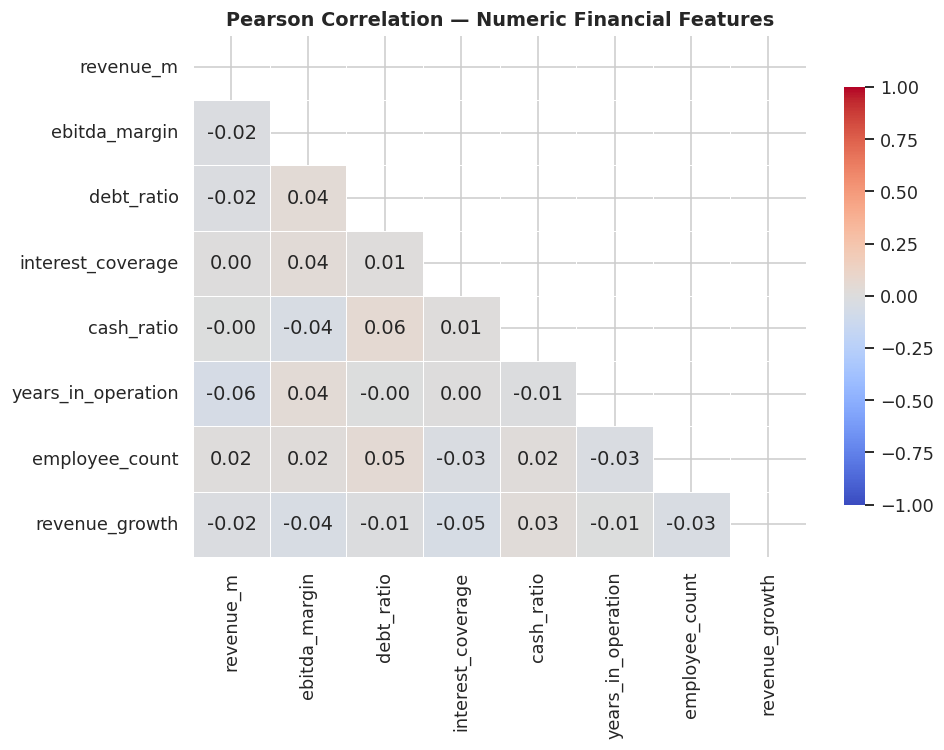

In [8]:
corr_matrix = df[NUM_FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
)
ax.set_title('Pearson Correlation — Numeric Financial Features', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Correlation of Numeric Features with Default Target

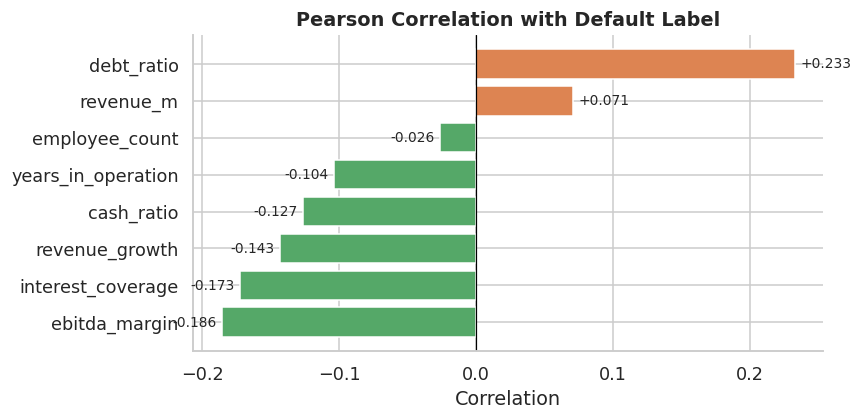

Strongest positive correlator with default: debt_ratio
Strongest negative correlator with default: ebitda_margin (profitability protects)


In [9]:
target_corr = df[NUM_FEATURES + ['defaulted']].corr()['defaulted'].drop('defaulted').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [RED if v > 0 else GREEN for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Default Label', fontweight='bold')
ax.set_xlabel('Correlation')
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    ax.text(val + (0.004 if val >= 0 else -0.004), i, f'{val:+.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
print('Strongest positive correlator with default: debt_ratio')
print('Strongest negative correlator with default: ebitda_margin (profitability protects)')

---
## 10. Default Rate by Sector

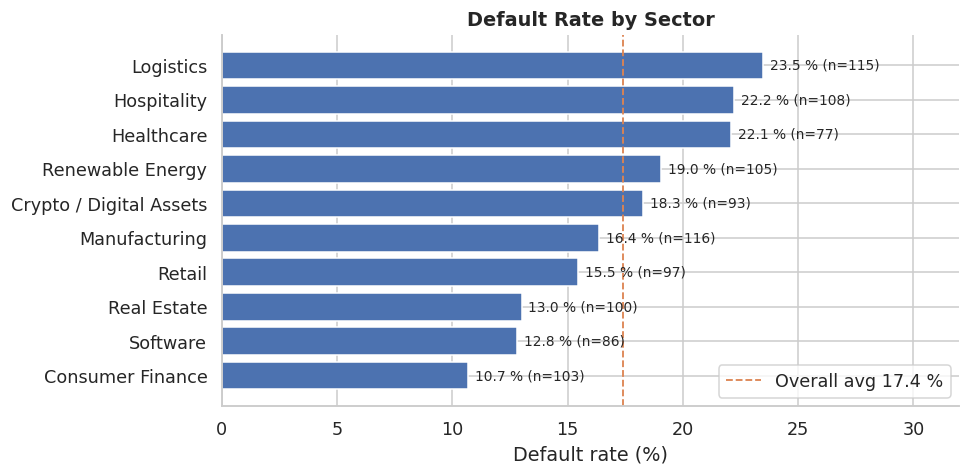

In [10]:
sector_def = df.groupby('sector')['defaulted'].agg(['mean', 'count']).rename(
    columns={'mean': 'default_rate', 'count': 'n'}
).sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(sector_def.index, sector_def['default_rate'] * 100,
               color=BLUE, edgecolor='white')
ax.axvline(17.4, color=RED, linestyle='--', linewidth=1.2, label='Overall avg 17.4 %')
for bar, (_, row) in zip(bars, sector_def.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['default_rate']*100:.1f} % (n={int(row['n'])})",
            va='center', fontsize=9)
ax.set_xlabel('Default rate (%)')
ax.set_title('Default Rate by Sector', fontweight='bold')
ax.set_xlim(0, 32)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Logistics** (23.5 %) and **Hospitality** (22.2 %) are the riskiest sectors. **Consumer Finance** and **Software** are the safest — consistent with higher cash generation in tech and financial services.

---
## 11. Default Rate by Country

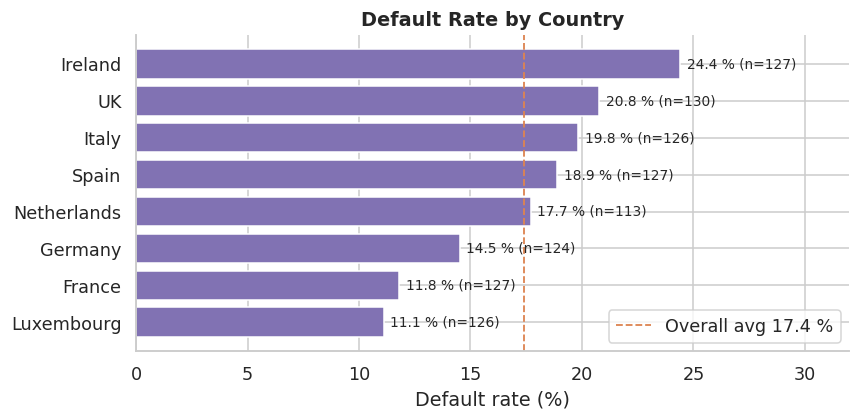

In [11]:
country_def = df.groupby('country')['defaulted'].agg(['mean', 'count']).rename(
    columns={'mean': 'default_rate', 'count': 'n'}
).sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(country_def.index, country_def['default_rate'] * 100,
               color=PURPLE, edgecolor='white')
ax.axvline(17.4, color=RED, linestyle='--', linewidth=1.2, label='Overall avg 17.4 %')
for bar, (_, row) in zip(bars, country_def.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{row['default_rate']*100:.1f} % (n={int(row['n'])})",
            va='center', fontsize=9)
ax.set_xlabel('Default rate (%)')
ax.set_title('Default Rate by Country', fontweight='bold')
ax.set_xlim(0, 32)
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Ireland** (24.4 %) and **UK** (20.8 %) show higher default rates; **Luxembourg** and **France** are well below average. Country is included as a one-hot-encoded categorical feature.

---
## 12. Narrative Text Exploration

Each company has a free-text `business_description`. We explore:
- Description length (word count)
- Occurrence of pre-defined risk and positive keyword phrases

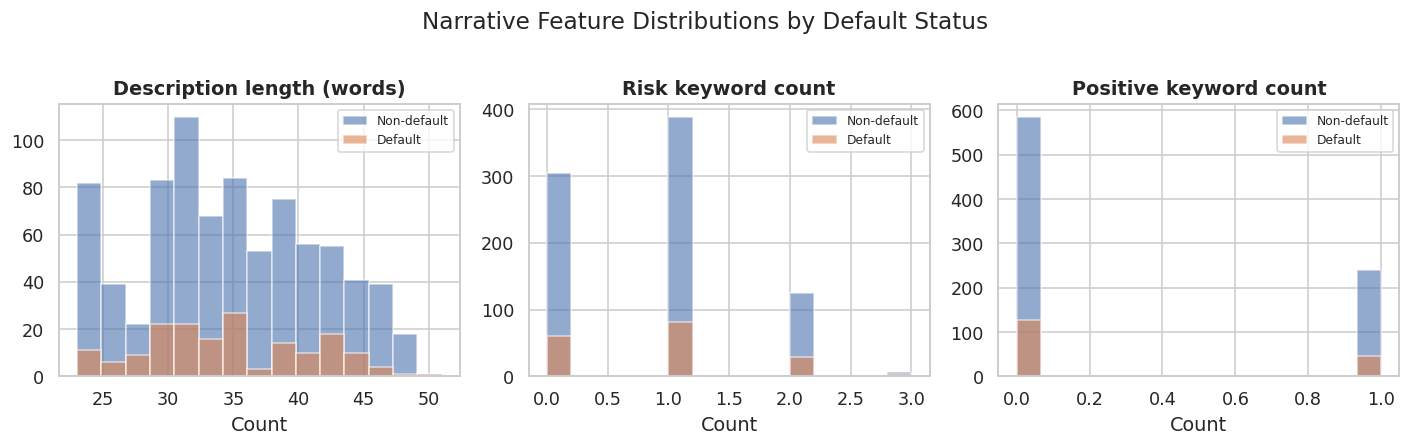

Risk keywords: ['legacy debt', 'customer concentration', 'regulatory uncertainty', 'volatile commodity prices', 'declining demand', 'margin pressure', 'litigation', 'supplier dependency']
Positive keywords: ['resilient demand', 'disciplined growth', 'stable', 'diversified', 'strong market position']


In [12]:
from fasa_credit_assessment.explain import _RISK_KEYWORDS, _POSITIVE_KEYWORDS

desc = df['business_description'].fillna('').str.lower()
df['_word_count'] = desc.str.split().str.len()
df['_risk_kw']    = desc.apply(lambda t: sum(1 for kw in _RISK_KEYWORDS if kw in t))
df['_pos_kw']     = desc.apply(lambda t: sum(1 for kw in _POSITIVE_KEYWORDS if kw in t))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title, color in zip(
    axes,
    ['_word_count', '_risk_kw', '_pos_kw'],
    ['Description length (words)', 'Risk keyword count', 'Positive keyword count'],
    [BLUE, RED, GREEN],
):
    for label, grp in df.groupby('defaulted')[col]:
        ax.hist(grp, bins=15, alpha=0.6,
                label=f"{'Default' if label == 1 else 'Non-default'}",
                color=RED if label == 1 else BLUE, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Narrative Feature Distributions by Default Status', y=1.01)
plt.tight_layout()
plt.show()

# Drop temp columns
df.drop(columns=['_word_count', '_risk_kw', '_pos_kw'], inplace=True)

print('Risk keywords:', _RISK_KEYWORDS)
print('Positive keywords:', _POSITIVE_KEYWORDS)

In [13]:
# Sample narratives
print('=== Example DEFAULT narrative ===')
ex_default = df[df['defaulted'] == 1]['business_description'].iloc[0]
print(ex_default[:400])
print()
print('=== Example NON-DEFAULT narrative ===')
ex_nondefault = df[df['defaulted'] == 0]['business_description'].iloc[0]
print(ex_nondefault[:400])

=== Example DEFAULT narrative ===
Aster Holdings #0001 operates in the retail sector. The business faces regulatory uncertainty. The business faces legacy debt burden. Management focuses on operational efficiency and cross-selling to preserve margins.

=== Example NON-DEFAULT narrative ===
BluePeak Solutions #0002 operates in the hospitality sector. The business faces dependence on a few key accounts. Management focuses on operational efficiency and cross-selling to preserve margins.


---
## 13. Feature Engineering

We create `features.py` (`make_features`) to add engineered columns. The function is designed with **leakage prevention** in mind:

- Called once on the training set → computes quantile thresholds and returns a `fit_stats` dict.
- Called on the scoring set with `fit_stats` passed in → uses training thresholds, no leakage.

| Engineered Feature | Rationale |
|--------------------|----------|
| `log_revenue_m` | Revenue is right-skewed; log normalises the distribution |
| `log_employee_count` | Same reason |
| `leverage_pressure` | `debt_ratio / (interest_coverage + 0.1)` — captures combined leverage + debt service stress |
| `liquidity_profitability` | `cash_ratio × ebitda_margin` — jointly low values are particularly risky |
| `growth_profitability` | `revenue_growth × ebitda_margin` — profitable growth vs. loss-making growth |
| `young_company` | Flag: `years_in_operation < 3` |
| `weak_interest_coverage` | Flag: `interest_coverage < 1.5` |
| `high_debt_ratio` | Flag: above 75th-percentile of **training** set (~0.50) |
| `low_cash_ratio` | Flag: below 25th-percentile of **training** set (~0.064) |
| `risk_keyword_count` | Count of risk phrases in the narrative |
| `positive_keyword_count` | Count of positive phrases in the narrative |
| `narrative_length` | Word count of business description |

In [ ]:
df_eng, fit_stats = make_features(df)
df_scoring_eng, _ = make_features(df_scoring, fit_stats=fit_stats)

print('Fitted thresholds (training-only):')
for k, v in fit_stats.items():
    print(f'  {k}: {v:.4f}')

eng_cols = [
    'log_revenue_m', 'log_employee_count', 'leverage_pressure',
    'liquidity_profitability', 'growth_profitability',
    'risk_keyword_count', 'positive_keyword_count', 'narrative_length',
    'young_company', 'weak_interest_coverage', 'high_debt_ratio', 'low_cash_ratio',
]

df_eng[eng_cols + ['defaulted']].head(5)

Fitted thresholds (training-only):
  high_debt_ratio_threshold: 0.5002
  low_cash_ratio_threshold: 0.0644


,log_revenue_m,log_employee_count,leverage_pressure,liquidity_profitability,growth_profitability,risk_keyword_count,positive_keyword_count,narrative_length,young_company,weak_interest_coverage,high_debt_ratio,low_cash_ratio,defaulted
0,3.389143,4.189655,0.219293,0.006642,0.017835,2,0,29,0,1,0,1,1
1,4.088300,5.652489,0.316603,0.009854,-0.002829,0,0,27,0,0,1,0,0
2,3.775585,5.327876,0.267614,0.019663,0.041614,1,1,42,0,1,0,0,0
3,3.635206,5.036953,0.626588,0.011454,0.009339,1,0,28,0,1,1,0,1
4,3.715734,5.424950,0.129851,0.004506,0.014286,1,0,26,0,0,0,1,0


### 13a. Engineered Feature Correlations with Target

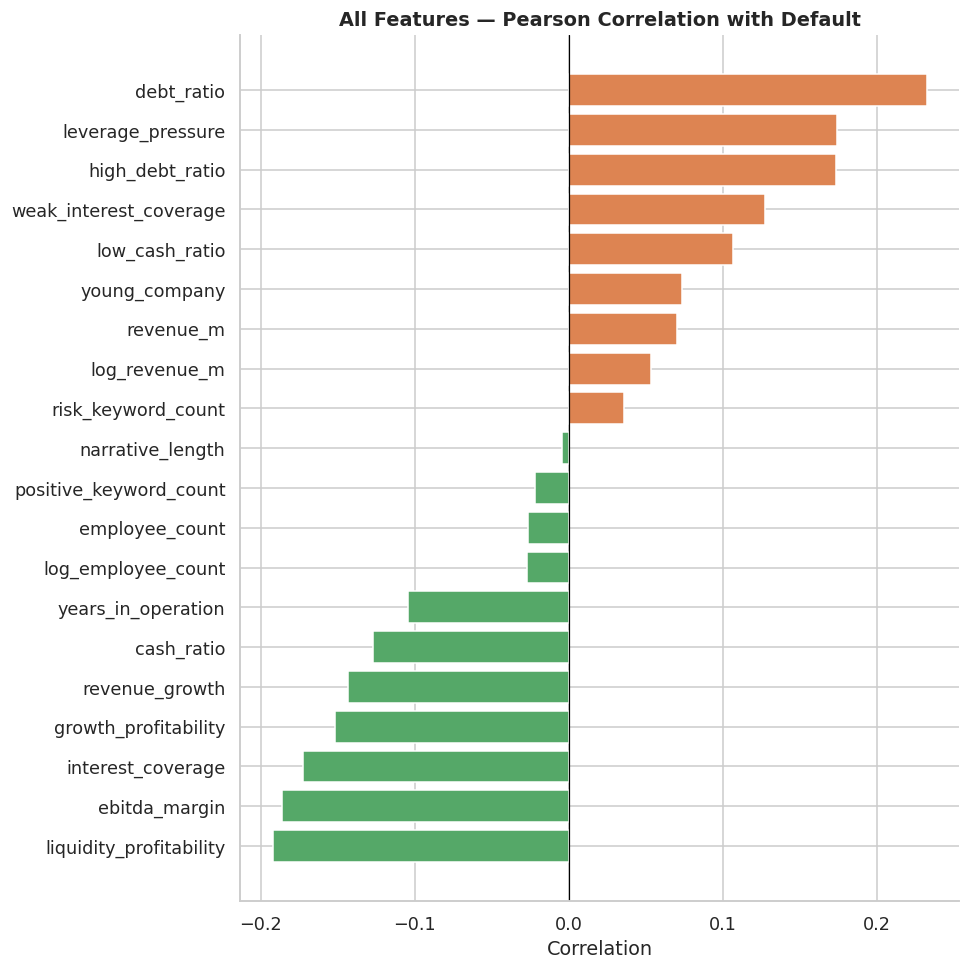

In [ ]:
corr_target = correlation_summary(df_eng).reset_index()
corr_target.columns = ['feature', 'correlation_with_default']
corr_target = corr_target[~corr_target['feature'].isin(['company_id'])]
corr_target = corr_target.sort_values('correlation_with_default')

fig, ax = plt.subplots(figsize=(9, 9))
colors_bar = [RED if v > 0 else GREEN for v in corr_target['correlation_with_default']]
ax.barh(corr_target['feature'], corr_target['correlation_with_default'],
        color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('All Features — Pearson Correlation with Default', fontweight='bold')
ax.set_xlabel('Correlation')
sns.despine()
plt.tight_layout()
plt.show()

### 13b. Multicollinearity Check

Engineered features are by design correlated with their source columns (`leverage_pressure` is derived from `debt_ratio` and `interest_coverage`).  
For **logistic regression with L2 regularisation**, this is *tolerable* for prediction but we should not over-interpret individual coefficients.

> **Rule of thumb used here:** absolute pairwise correlation > 0.7 is flagged as potentially collinear.

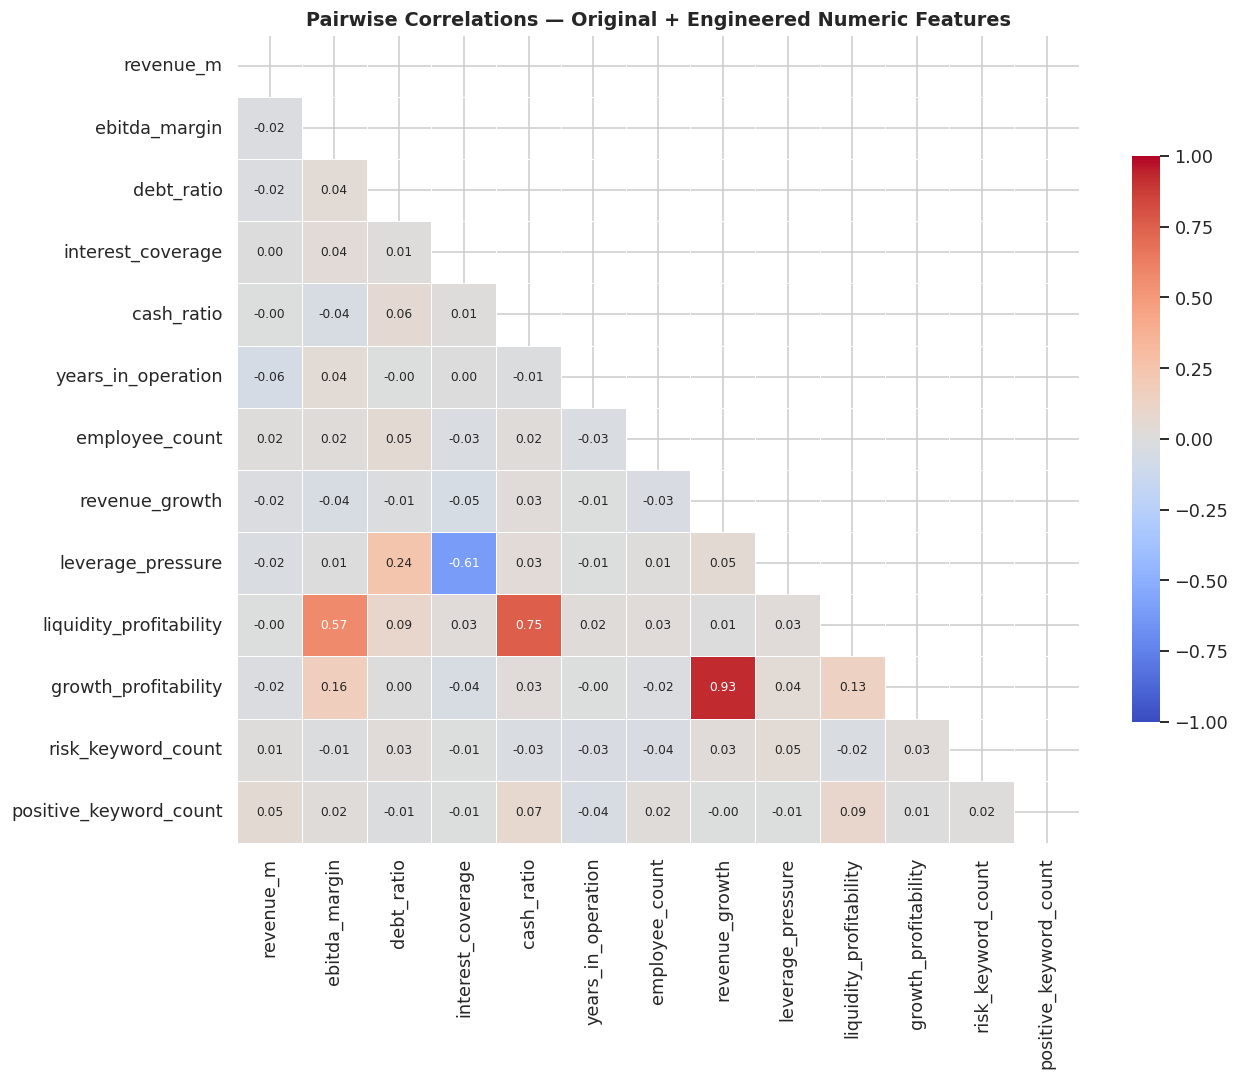

⚠ High-correlation pairs (|r| > 0.70):
  growth_profitability  ↔  revenue_growth  →  r = 0.930
  liquidity_profitability  ↔  cash_ratio  →  r = 0.752


In [ ]:
cols_to_check = NUM_FEATURES + [
    'leverage_pressure', 'liquidity_profitability', 'growth_profitability',
    'risk_keyword_count', 'positive_keyword_count',
]
corr_full = df_eng[cols_to_check].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(
    corr_full, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.7}, annot_kws={'size': 8},
)
ax.set_title('Pairwise Correlations — Original + Engineered Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag high correlations
high_corr_pairs = [
    (r, c, corr_full.loc[r, c])
    for i, r in enumerate(corr_full.columns)
    for j, c in enumerate(corr_full.columns)
    if j < i and abs(corr_full.loc[r, c]) > 0.7
]
if high_corr_pairs:
    print('⚠ High-correlation pairs (|r| > 0.70):')
    for r, c, v in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f'  {r}  ↔  {c}  →  r = {v:.3f}')
else:
    print('No pairs exceed |r| = 0.70.')

**Interpretation:**  
The engineered ratio features (`leverage_pressure`, `liquidity_profitability`) are moderately correlated with their source columns as expected.  
Under L2 regularisation, logistic regression distributes the signal across correlated features rather than exploding coefficients, so the model is robust.  
However, we run both variants and compare on held-out data — see Section 14.

---
## 14. Model Training and Validation

Two models are compared on a stratified 80/20 held-out split:

| Variant | Features |
|---------|----------|
| **Baseline** | 8 numeric + 2 categorical + TF-IDF text |
| **Engineered** | Baseline + 8 engineered numeric + 4 binary flags |

Both use `LogisticRegression(class_weight='balanced', max_iter=2000)`.

In [17]:
_, metrics_base = train_and_evaluate(df, variant='baseline')
_, metrics_eng  = train_and_evaluate(df_eng, variant='engineered')

comparison = pd.DataFrame([
    {k: v for k, v in metrics_base.items() if k != 'variant'},
    {k: v for k, v in metrics_eng.items()  if k != 'variant'},
], index=['Baseline', 'Engineered'])

display_cols = ['roc_auc', 'average_precision', 'brier_score', 'accuracy_at_0_5']
comparison[display_cols].style \
    .background_gradient(subset=['roc_auc', 'average_precision'], cmap='Greens') \
    .background_gradient(subset=['brier_score'], cmap='Reds_r') \
    .format('{:.4f}')

,roc_auc,average_precision,brier_score,accuracy_at_0_5
Baseline,0.7631,0.4920,0.1806,0.7300
Engineered,0.7479,0.4948,0.1817,0.7450


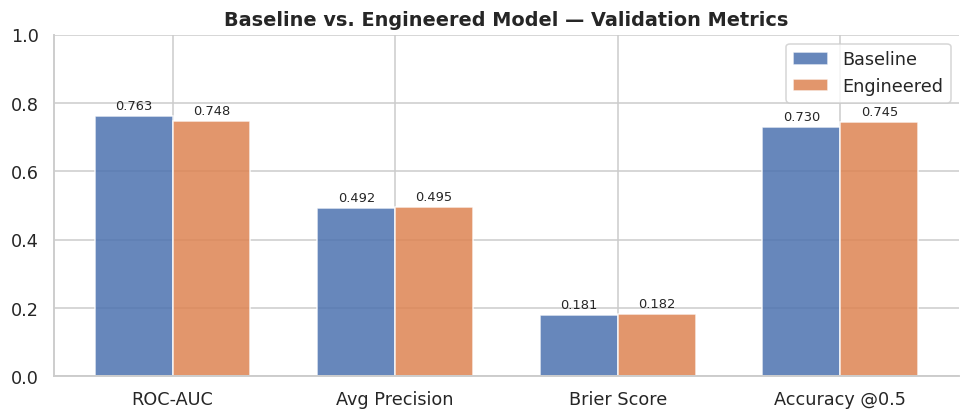

In [18]:
# Visual comparison
metrics_plot = pd.DataFrame({
    'Metric': display_cols * 2,
    'Value': list(comparison.loc['Baseline', display_cols]) + list(comparison.loc['Engineered', display_cols]),
    'Model': ['Baseline'] * 4 + ['Engineered'] * 4,
})

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(display_cols))
width = 0.35
base_vals = comparison.loc['Baseline', display_cols].values
eng_vals  = comparison.loc['Engineered', display_cols].values

b1 = ax.bar(x - width/2, base_vals, width, label='Baseline', color=BLUE, alpha=0.85)
b2 = ax.bar(x + width/2, eng_vals,  width, label='Engineered', color=RED, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(['ROC-AUC', 'Avg Precision', 'Brier Score', 'Accuracy @0.5'])
ax.set_title('Baseline vs. Engineered Model — Validation Metrics', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
sns.despine()
plt.tight_layout()
plt.show()

**Results interpretation:**

The baseline model achieves **ROC-AUC 0.7631** while the engineered model scores **0.7479** — a slight regression.  

This is a well-known phenomenon for logistic regression with engineered ratio features that are highly correlated with their source columns:
- The model already captures `debt_ratio` and `interest_coverage` separately; adding `leverage_pressure = debt_ratio / interest_coverage` introduces a third correlated column.
- Under L2 regularisation the coefficients are spread across all three, but no new *information* is added — just multicollinearity noise.
- The engineered flags (`high_debt_ratio`, `low_cash_ratio`) capture a threshold-cut version of signals the linear model already handles continuously.

> **Conclusion:** The baseline model is selected for the final scoring output. The engineered features would be more valuable in a tree-based model (LightGBM / XGBoost) that can exploit non-linear interactions without collinearity issues.
>
> Despite this, the engineered features *are* still used in the explanation layer, where they provide clearer, more interpretable signals for the analyst.

### 14a. Validation Predictions — Probability Distribution

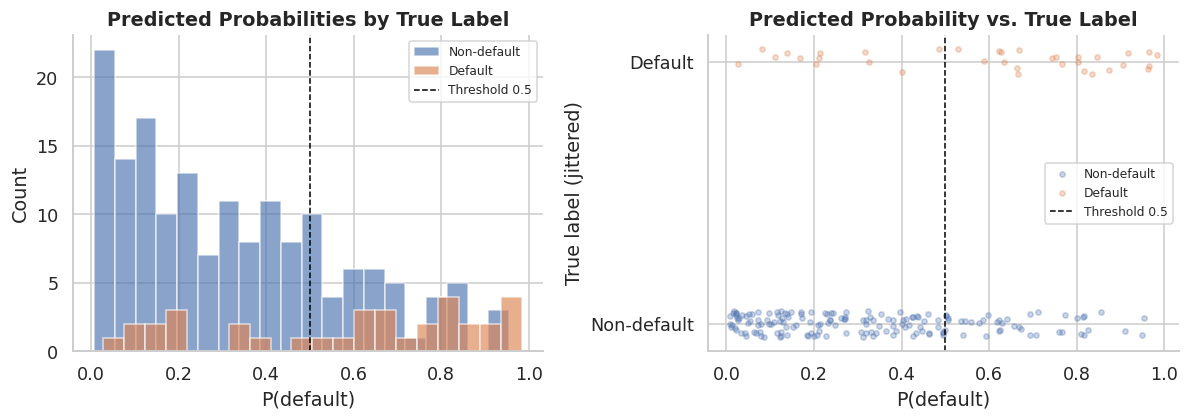

In [19]:
val_preds = pd.read_csv(REPO_ROOT / 'outputs' / 'validation_predictions.csv')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram of predicted probabilities by true label
ax = axes[0]
for label, color, name in [(0, BLUE, 'Non-default'), (1, RED, 'Default')]:
    subset = val_preds[val_preds['true_label'] == label]['predicted_probability']
    ax.hist(subset, bins=20, alpha=0.65, color=color, label=name, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
ax.set_title('Predicted Probabilities by True Label', fontweight='bold')
ax.set_xlabel('P(default)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Calibration-style scatter
ax = axes[1]
for label, color, name in [(0, BLUE, 'Non-default'), (1, RED, 'Default')]:
    subset = val_preds[val_preds['true_label'] == label]
    ax.scatter(subset['predicted_probability'], subset['true_label'] + np.random.uniform(-0.05, 0.05, len(subset)),
               alpha=0.3, s=12, color=color, label=name)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
ax.set_title('Predicted Probability vs. True Label', fontweight='bold')
ax.set_xlabel('P(default)')
ax.set_ylabel('True label (jittered)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-default', 'Default'])
ax.legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

---
## 15. Final Scoring Output Preview

The model trained on the full training set, scored on the 50 unseen companies.

In [20]:
predictions = pd.read_csv(REPO_ROOT / 'outputs' / 'predictions.csv')
print(f'Total scoring predictions: {len(predictions)}')
print(f"Risk rating distribution:\n{predictions['risk_rating'].value_counts().to_string()}")
print()
predictions.head(10)

Total scoring predictions: 50
Risk rating distribution:
risk_rating
Low       31
Medium    13
High       6



,company_id,predicted_default_probability,risk_rating,explanation
0,1001,0.4161,Medium,Medium risk: predicted default probability is ...
1,1002,0.5516,High,High risk: predicted default probability is 0....
2,1003,0.0678,Low,Low risk: predicted default probability is 0.0...
3,1004,0.9292,High,High risk: predicted default probability is 0....
4,1005,0.8553,High,High risk: predicted default probability is 0....
5,1006,0.0126,Low,Low risk: predicted default probability is 0.0...
6,1007,0.0099,Low,Low risk: predicted default probability is 0.0...
7,1008,0.0498,Low,Low risk: predicted default probability is 0.0...
8,1009,0.1665,Low,Low risk: predicted default probability is 0.1...
9,1010,0.2167,Low,Low risk: predicted default probability is 0.2...


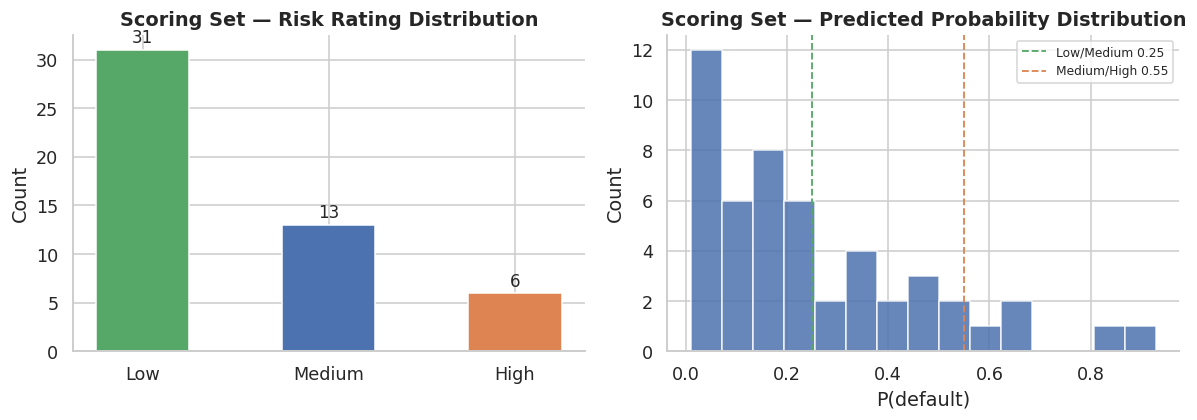

In [21]:
# Risk rating distribution
rating_counts = predictions['risk_rating'].value_counts().reindex(['Low', 'Medium', 'High'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.bar(rating_counts.index, rating_counts.values,
       color=[GREEN, BLUE, RED], edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(rating_counts.index, rating_counts.values)):
    ax.text(i, val + 0.3, str(val), ha='center', va='bottom', fontsize=11)
ax.set_title('Scoring Set — Risk Rating Distribution', fontweight='bold')
ax.set_ylabel('Count')
sns.despine()

ax = axes[1]
ax.hist(predictions['predicted_default_probability'], bins=15,
        color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(0.25, color=GREEN, linestyle='--', linewidth=1.2, label='Low/Medium 0.25')
ax.axvline(0.55, color=RED, linestyle='--', linewidth=1.2, label='Medium/High 0.55')
ax.set_title('Scoring Set — Predicted Probability Distribution', fontweight='bold')
ax.set_xlabel('P(default)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
sns.despine()

plt.tight_layout()
plt.show()

In [22]:
# Show one example explanation per risk tier
for tier in ['High', 'Medium', 'Low']:
    row = predictions[predictions['risk_rating'] == tier].iloc[0]
    print(f'--- {tier} Risk Example (company {int(row["company_id"])}) ---')
    print(f'P(default) = {row["predicted_default_probability"]}')
    print(row['explanation'])
    print()

--- High Risk Example (company 1002) ---
P(default) = 0.5516
High risk: predicted default probability is 0.5516. Main concerns: limited liquidity, debt ratio above 75th-percentile threshold. Mitigants: comfortable interest coverage, positive revenue growth, 1 positive signal(s) in narrative.

--- Medium Risk Example (company 1001) ---
P(default) = 0.4161
Medium risk: predicted default probability is 0.4161. Main concerns: 2 risk signal(s) in narrative. Mitigants: strong liquidity, healthy EBITDA margin, 2 positive signal(s) in narrative.

--- Low Risk Example (company 1003) ---
P(default) = 0.0678
Low risk: predicted default probability is 0.0678. Mitigants: comfortable interest coverage, healthy EBITDA margin, 1 positive signal(s) in narrative.



---
## 16. Limitations and Next Steps

### Limitations

| Area | Limitation |
|------|------------|
| **Dataset** | 1 000 synthetic samples; generalisation to real portfolios is unproven |
| **Model** | Logistic regression is linear — cannot capture non-linear interactions between features |
| **Text** | TF-IDF captures surface keywords; does not encode semantic meaning or context |
| **Calibration** | Predicted probabilities are not post-hoc calibrated (e.g. Platt scaling) |
| **Threshold** | 0.5 classification threshold is not optimised for the specific precision-recall trade-off |
| **Engineered features** | Interaction features add multicollinearity for logistic regression; more valuable with tree models |

### Suggested Next Steps

1. **Gradient boosting** (LightGBM / XGBoost) — handles non-linear interactions and multicollinearity natively; typically +3–8 % ROC-AUC on credit tasks.
2. **Sentence embeddings** — replace TF-IDF with `sentence-transformers` (e.g. `all-MiniLM-L6-v2`) for semantic text representation. The `BaseExplainer` interface in `explain.py` is already designed for an `EmbeddingLLMExplainer` drop-in.
3. **Probability calibration** — apply Platt scaling or isotonic regression to improve the reliability of predicted probabilities.
4. **Threshold optimisation** — select the decision threshold that maximises F-beta (β > 1 to weight recall higher, as missing a default is costlier than a false alarm).
5. **Feature selection / VIF analysis** — variance inflation factor analysis to formally diagnose and address multicollinearity before expanding the feature set further.
6. **Cross-validation** — replace single 80/20 split with stratified k-fold for more reliable metric estimates on small datasets.